# Building Conv Model that can predict the rotation on one symbol

## Prepare data

In [1]:
import tensorflow as tf
import glob
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import re

I0000 00:00:1780501667.489813  227377 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780501668.827799  227377 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780501674.543641  227377 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data_path = "/content/my_dataset/model_2/*"

In [4]:
!mkdir -p /content/my_dataset

In [5]:
!unzip -q /content/drive/MyDrive/ml_datasets/captcha_decoder/dataset_for_3_models.zip -d /content/my_dataset

In [6]:
pattern = r"_angle_(-?\d+)"
img_paths = list(glob.glob(data_path))

list_of_imgs = []
list_of_angles = []

for p in img_paths:
    clean_filename = os.path.basename(p)
    match = re.search(pattern, clean_filename)

    if not match:
        continue

    angle = int(match.group(1))
    list_of_angles.append(angle)

    img = img_to_array(load_img(p, target_size=(52, 36), color_mode="grayscale"))
    list_of_imgs.append(img)


X = np.array(list_of_imgs, dtype=np.float32) / 255.0
Y = np.array(list_of_angles, dtype=np.int32)

In [9]:
Y, len(Y)

(array([  3, -21,  -1, ...,   2,  19,  -4], dtype=int32), 54932)

In [32]:
y_train = Y / 25.0
y_train

array([ 0.12, -0.84, -0.04, ...,  0.08,  0.76, -0.16])

In [33]:
X.shape

(54932, 52, 36, 1)

In [34]:
X_train = X.copy()
X_train[X_train < 0.5] = 0.0
X_train[X_train >= 0.5] = 1.0

np.unique(X_train)

array([0., 1.], dtype=float32)

In [30]:
idx = 6011
Y[idx]

np.int32(-23)

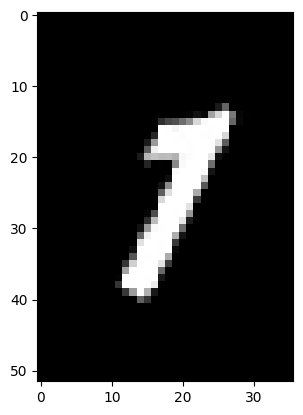

In [31]:
plt.imshow(X[idx], cmap="gray")

## Build Model

In [35]:
inp = tf.keras.layers.Input(shape=(52, 36, 1))

x = tf.keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same')(inp)
x = tf.keras.layers.MaxPooling2D()(x) # 26x18

x = tf.keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPooling2D()(x) # 13x9

x = tf.keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same')(x)
x = tf.keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same')(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)

out = tf.keras.layers.Dense(1, activation='tanh')(x)

In [36]:
model = tf.keras.models.Model(inputs=inp, outputs=out)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 52, 36, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 52, 36, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 9, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 9, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7488)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       958,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,051,393 (4.01 MB)

 Trainable params: 1,051,393 (4.01 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
rmse = tf.keras.metrics.RootMeanSquaredError(name='rmse')
model.compile(optimizer='adam', loss='mse', metrics=[rmse, 'mae'])


early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="drive/MyDrive/ml_models/rotation/best_rotation_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    shuffle=True,
    callbacks=[early_stopping, checkpoint_callback]
)

Epoch 1/15
773/773 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0384 - mae: 0.1291 - rmse: 0.1821
Epoch 1: val_loss improved from None to 0.00735, saving model to drive/MyDrive/ml_models/rotation/best_rotation_model.keras

Epoch 1: finished saving model to drive/MyDrive/ml_models/rotation/best_rotation_model.keras
773/773 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 0.0172 - mae: 0.0923 - rmse: 0.1312 - val_loss: 0.0073 - val_mae: 0.0647 - val_rmse: 0.0857
Epoch 2/15
767/773 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0079 - mae: 0.0683 - rmse: 0.0888
Epoch 2: val_loss improved from 0.00735 to 0.00479, saving model to drive/MyDrive/ml_models/rotation/best_rotation_model.keras

Epoch 2: finished saving model to drive/MyDrive/ml_models/rotation/best_rotation_model.keras
773/773 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 0.0074 - mae: 0.0664 - rmse: 0.0861 - val_loss: 0.0048 - val_mae: 0.0525 - val_rmse: 0.0692
Epoch 3/15
769/773 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0061 - mae: 0.0607 - 

In [38]:
model.save("drive/MyDrive/ml_models/rotation/best_rotation_model.keras")

### Local Test

In [2]:
pattern = r"_angle_(-?\d+)"


def preprocesing_img(img_path):
    clean_filename = os.path.basename(img_path)
    match = re.search(pattern, clean_filename)
    
    angle = int(match.group(1))

    img = img_to_array(load_img(img_path, target_size=(52, 36), color_mode="grayscale")) / 255.0
    return img[np.newaxis, ...], angle

In [5]:
model = tf.keras.models.load_model("models/best_rotation_model.keras")

E0000 00:00:1780502074.701718  227377 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted angle: 8.668468475341797, Actual angle: 10


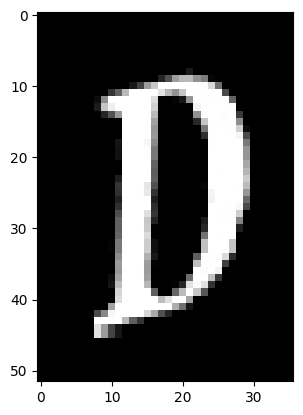

In [21]:
paths = glob.glob("../dataset/model_2/*")
idx = np.random.randint(0, len(paths) - 1)

img_path = paths[idx]
img, angle = preprocesing_img(img_path)

y_pred = model.predict(img) * 25.0
print(f"Predicted angle: {y_pred[0][0]}, Actual angle: {angle}")
plt.imshow(img[0], cmap="gray")